# AGN point-source detectability from an astromodels YAML

Test the catalog flux of each AGN independently over **0.1–10 MeV (100–10,000 keV)**.
This extends [PointSource_Sensitivity.ipynb](PointSource_Sensitivity.ipynb) to cutoff
power laws loaded from a combined YAML. The defaults are **all 13 sources and 20
Poisson realizations per source**, using the DC4 three-month continuum response,
background, and spacecraft history. A separate two-year result is an approximate
extrapolation, not a two-year simulation.

Each trial fits source normalization and background rate, keeping position and
spectral shape fixed. Other AGNs in the YAML are **not** included in that trial:
this is isolated-source detectability, not a simultaneous sky fit. These tests do
not search for the minimum detectable flux. Twenty trials provide only an
exploratory estimate of median TS; increase the trial count for stable results.

## Generate the input model

In the Python environment containing astromodels and scipy, run:

```bash
cd /path/to/AGN-HE-detectability
python generate_cosi_agn_model.py
# To regenerate an existing model: add --overwrite
```

The generator reads `AGN_Index_ecut_scatter_cosi_detectable.csv` and the local
`Swift_BAT_105mo_catalog.csv`, obtains counterpart positions, and saves
`cosi_agn_models.yaml`. Set `MODEL_PATH` below if your repositories are not siblings.
The original CSV and its 0.2–5 MeV flux columns are not needed at notebook runtime.

For photon spectrum $N(E)=K(E/1\,\mathrm{keV})^{-\Gamma}\exp(-E/E_c)$,
`index = -Gamma`, `xc = Ecut_keV`, and `K = norm_at_1_keV / 1.602176634e-9`.
The CSV normalization is an **energy-flux coefficient**, not a photon normalization.
BAT 14–195 keV normalization is preserved; we integrate the loaded spectra anew
over **100–10,000 keV**. This changes the reporting band without renormalizing the source.

Use a Python 3.12+ kernel with this cosipy checkout and its dependencies installed.
The continuum response is coarse; these estimates inherit its limitations and the
assumed background model. Large response downloads and source-response calculations
can take substantial time and memory.

Results and tables are displayed inline and kept in memory. The notebook does not
write result CSVs, plots, metadata, checkpoints, or projection caches. Optional
reference-data downloads remain separate from calculation outputs. A restart
requires rerunning calculations; normal notebook saving can retain displayed outputs.


In [1]:
import os
# Set before importing numerical libraries.
for variable in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[variable] = "1"

import hashlib
import h5py
import healpy as hp
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
from IPython.display import display
from scipy.integrate import quad
from astromodels import Cutoff_powerlaw, Parameter, clone_model, load_model
from astromodels.utils.configuration import astromodels_config
from threeML import DataList, JointLikelihood
from histpy import Histogram

from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response import (
    FullDetectorResponse, BinnedInstrumentResponse,
    BinnedThreeMLPointSourceResponse, BinnedThreeMLModelFolding,
)
from cosipy.data_io import EmCDSBinnedData
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.statistics import PoissonLikelihood
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.util import fetch_wasabi_file

logging.getLogger("cosipy").setLevel(logging.WARNING)


def display_tables(*tables):
    # Display every row and column; no CSV/HTML export is performed.
    with pd.option_context("display.max_rows", None, "display.max_columns", None):
        for table in tables:
            display(table)


12:38:23 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=210828;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=779071;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=510705;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=210916;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

12:38:24 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=196654;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=299352;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

12:38:24 INFO      Starting 3ML!                                                                     ]8;id=332096;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=902888;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=908861;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=996144;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   ROOT minimizer not available                                                ]8;id=302960;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=292032;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py#1208\1208]8;;\

         WARNING   Multinest minimizer not available                                           ]8;id=873269;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=845534;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py#1218\1218]8;;\

         WARNING   PyGMO is not available                                                      ]8;id=418523;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=863186;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py#1228\1228]8;;\

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=572617;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=484550;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=640749;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=279324;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

In [2]:
# Works from the cosipy repository root or any directory beneath it.
COSI_ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "cosipy").is_dir() and (p / "pyproject.toml").is_file()),
    Path.cwd(),
)
MODEL_PATH = COSI_ROOT.parent / "AGN-HE-detectability" / "cosi_agn_models.yaml"
# Reuse the user's existing DC4 files without writing into the OneDrive folder.
DATA_DIR = (Path.home() / "Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/"
            "Radio_Quiet_AGN/DC4_Files")
DOWNLOAD_DIR = COSI_ROOT / "agn_sensitivity_data"  # Only missing reference files.
TOTAL_BACKGROUND_PATH = DATA_DIR / "Background/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck.hdf5"
FOV_MAX_OFFAXIS_DEG = 60.0  # Radius from spacecraft +Z; used only for the FOV estimate.
SOURCE_NAMES = None  # None = all sources; e.g. ["CenA", "NGC2110"] for a subset.
N_REALIZATIONS = 20
RANDOM_SEED = 20260916
DOWNLOAD_DATA = False  # All three files are now in DATA_DIR; True fetches missing files.
ENERGY_BAND_KEV = (100.0, 10000.0)
TS_THRESHOLD = 9.0
EXPOSURE_SCALE_2YR = 8.0  # 24 months / nominal 3-month DC4 history.
BACKGROUND_FLOOR_COUNTS = 1e-12  # Applied only to exactly empty background bins.

if not MODEL_PATH.is_file():
    raise FileNotFoundError(f"Generate the YAML first or update MODEL_PATH: {MODEL_PATH}")
if not isinstance(N_REALIZATIONS, int) or N_REALIZATIONS < 1:
    raise ValueError("N_REALIZATIONS must be a positive integer")
if not isinstance(RANDOM_SEED, int) or RANDOM_SEED < 0:
    raise ValueError("RANDOM_SEED must be a nonnegative integer")


## Load and inspect the catalog spectra

All reported photon/energy fluxes below cover **0.1–10 MeV**. `K` is the coefficient
of the cutoff power law at a 1 keV pivot (the exponential still multiplies it).
Only the fitted model copies are changed; the loaded catalog model stays unchanged.


In [3]:
KEV_TO_ERG = 1.602176634e-9


def band_fluxes(shape, band=(100.0, 10000.0)):
    photon = quad(lambda e: float(shape(e)), *band, epsabs=1e-30, epsrel=1e-9)[0]
    energy = quad(lambda e: e * float(shape(e)), *band, epsabs=1e-30, epsrel=1e-9)[0]
    return photon, energy * KEV_TO_ERG


def select_sources(catalog, names=None):
    available = list(catalog.point_sources)
    if catalog.extended_sources or not available:
        raise ValueError("Expected a YAML containing only point sources")
    selected = available if names is None else list(names)
    if not selected or len(selected) != len(set(selected)):
        raise ValueError("Choose at least one source, without duplicates")
    unknown = set(selected) - set(available)
    if unknown:
        raise ValueError(f"Unknown sources: {sorted(unknown)}; available: {available}")
    for name in selected:
        source = catalog.point_sources[name]
        if len(source.components) != 1 or not isinstance(source.spectrum.main.shape, Cutoff_powerlaw):
            raise ValueError(f"{name}: expected one Cutoff_powerlaw component")
        shape = source.spectrum.main.shape
        if not np.all(np.isfinite([shape.K.value, shape.index.value, shape.xc.value, shape.piv.value])):
            raise ValueError(f"{name}: nonfinite spectral parameters")
        if shape.K.value <= 0 or shape.xc.value <= 0 or shape.piv.value <= 0:
            raise ValueError(f"{name}: K, xc and piv must be positive")
    return selected


def isolated_model(catalog, name):
    model = clone_model(catalog)
    for other in list(model.point_sources):
        if other != name:
            model.remove_source(other)
    for parameter in model.parameters.values():
        parameter.free = False
    shape = model.point_sources[name].spectrum.main.shape
    # YAML loading restores the function's default log transform. Remove it here,
    # so the nested background-only hypothesis can have EXACTLY zero source flux.
    shape.K.remove_transformation()
    shape.K.min_value = 0.0
    shape.K.max_value = None
    shape.K.delta = 0.1 * shape.K.value
    shape.K.free = True
    return model


def source_table(catalog, names, band):
    rows = []
    for name in names:
        source = catalog.point_sources[name]
        shape = source.spectrum.main.shape
        photon, energy = band_fluxes(shape, band)
        rows.append({
            "source": name, "ra_deg": source.position.ra.value,
            "dec_deg": source.position.dec.value, "gamma": -shape.index.value,
            "ecut_keV": shape.xc.value, "K_ph_cm2_s_keV": shape.K.value,
            "band_min_keV": band[0], "band_max_keV": band[1],
            "photon_flux_0p1_10_MeV_ph_cm2_s": photon,
            "energy_flux_0p1_10_MeV_erg_cm2_s": energy,
        })
    return pd.DataFrame(rows)


In [4]:
catalog_model = load_model(str(MODEL_PATH))
selected_names = select_sources(catalog_model, SOURCE_NAMES)
catalog_table = source_table(catalog_model, selected_names, ENERGY_BAND_KEV)
display_tables(catalog_table)


,source,ra_deg,dec_deg,gamma,ecut_keV,K_ph_cm2_s_keV,band_min_keV,band_max_keV,photon_flux_0p1_10_MeV_ph_cm2_s,energy_flux_0p1_10_MeV_erg_cm2_s
0,CenA,201.3651,-43.0191,1.765,550.0,0.142014,100.0,10000.0,0.002911,1.116576e-09
1,NGC2110,88.0474,-7.4562,1.640,300.0,0.023406,100.0,10000.0,0.000660,2.199910e-10
2,NGC4388,186.4448,12.6621,1.640,210.0,0.021981,100.0,10000.0,0.000468,1.402858e-10
3,NGC5252,204.5665,4.5426,1.670,330.0,0.008104,100.0,10000.0,0.000208,7.083737e-11
4,Mrk3,93.9015,71.0375,1.520,150.0,0.008366,100.0,10000.0,0.000233,6.501604e-11
5,MCG_05_23_016,146.9173,-30.9489,1.930,150.0,0.057455,100.0,10000.0,0.000202,5.265450e-11
6,NGC7582,349.5979,-42.3706,1.700,200.0,0.008365,100.0,10000.0,0.000125,3.658744e-11
7,NGC6300,259.2478,-62.8206,1.850,210.0,0.017355,100.0,10000.0,0.000126,3.619704e-11
8,NGC788,30.2769,-6.8155,1.700,200.0,0.007880,100.0,10000.0,0.000118,3.446637e-11
9,NGC5506,213.3119,-3.2075,1.790,110.0,0.044336,100.0,10000.0,0.000214,5.298533e-11


## Obtain the DC4 continuum files

These are the same continuum choices and checksums provided in the original point-source
tutorial. Existing matching files are reused. The background histogram represents counts
for the supplied three-month history; its fitted normalization is a rate in Hz.

The default `DATA_DIR` is the supplied OneDrive `DC4_Files` directory. The response,
15-second orientation, and downloaded smoothed continuum background there match
the reference checksums. Its
`Background/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck.hdf5`
provides time-resolved counts for the FOV estimate below. The likelihood
calculation continues to use the reference smoothed background. With `DOWNLOAD_DATA = True`, missing reference
files are downloaded to `DOWNLOAD_DIR` in the cosipy workspace. The notebook only
reads files already present in `DATA_DIR`.


In [5]:
FILES = {
    "orientation": (
        "Orientation/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits",
        "ca94ff1d7a73c1f41479aaf598807673",
    ),
    "response": (
        "Responses/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5",
        "7121f094be50e7bfe9b31e53015b0e85",
    ),
    "background": (
        "Backgrounds/gal_DC4_bkg_continuum_binned_smoothed_fwhm_10.0deg.hdf5",
        "1acceb619b0d7e43eea8cb29ffe74279",
    ),
}
paths = {}
for key, (remote, _) in FILES.items():
    filename = Path(remote).name
    candidates = (DATA_DIR / filename, DATA_DIR / "Background" / filename,
                  DOWNLOAD_DIR / filename)
    paths[key] = next((path for path in candidates if path.is_file()), DOWNLOAD_DIR / filename)
    print(f"{key}: {paths[key]}")
for key, (remote, checksum) in FILES.items():
    if DOWNLOAD_DATA and not paths[key].is_file():
        paths[key].parent.mkdir(parents=True, exist_ok=True)
        fetch_wasabi_file("COSI-SMEX/DC4/Data/" + remote,
                          output=paths[key], checksum=checksum)
    elif not paths[key].is_file():
        raise FileNotFoundError(paths[key])
    else:
        # Streaming avoids loading a large response into memory just to hash it.
        with paths[key].open("rb") as handle:
            actual = hashlib.file_digest(handle, "md5").hexdigest()
        if actual != checksum:
            raise ValueError(f"Checksum mismatch: {paths[key]}")


orientation: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits
response: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5
background: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/gal_DC4_bkg_continuum_binned_smoothed_fwhm_10.0deg.hdf5


## Check the response and background

Use all native bins, without an additional measured-energy cut. Both incident and
measured energy coverage are checked against **100–10,000 keV**. No partial-bin
rescaling is applied. Scattering-angle bins must also agree; cosipy handles the
rotation from spacecraft coordinates to the background's sky coordinates.

Exactly empty background bins require care in a Poisson likelihood. We apply the
explicit, tiny floor configured above to those bins, using the same template for
simulation and fitting. This is a numerical convention, **not a measured physical
background**. Signal in such bins can inflate TS; the summary reports its expected
counts and the number of floored bins so these cases can be inspected.


In [6]:
def regularize_background(histogram, floor):
    background = histogram.project("Em", "Phi", "PsiChi").to_dense()
    values = np.asarray(background.contents, dtype=float).copy()
    if not np.all(np.isfinite(values)) or np.any(values < 0) or values.sum() <= 0:
        raise ValueError("Background must contain finite nonnegative counts with positive total")
    if not np.isfinite(floor) or floor <= 0:
        raise ValueError("The background floor must be finite and positive")
    empty = values == 0
    values[empty] = floor
    background[:] = values
    return background, empty


def check_response_axes(detector_response, background, band):
    for label, axis in (("Ei", detector_response.axes["Ei"]),
                        ("Em", detector_response.measurement_axes["Em"]),
                        ("background Em", background.axes["Em"])):
        edges = axis.edges.to_value(u.keV)
        if not np.all(np.diff(edges) > 0) or not np.allclose(edges[[0, -1]], band):
            raise ValueError(f"{label} must span {band} keV; got {edges[[0, -1]]}")
    for label in ("Em", "Phi"):
        if background.axes[label] != detector_response.measurement_axes[label]:
            raise ValueError(f"Background/response {label} axes do not match")
    if background.axes["PsiChi"].coordsys is None:
        raise ValueError("Background PsiChi axis needs a coordinate system")


def make_folding(model, detector_response, background, orientation):
    # Only axes enter the response construction. Trial counts go into a fresh
    # PoissonLikelihood; no private response data attributes need to be changed.
    template_data = EmCDSBinnedData(background)
    instrument = BinnedInstrumentResponse(detector_response, template_data)
    psr = BinnedThreeMLPointSourceResponse(
        data=template_data, instrument_response=instrument, sc_history=orientation,
        energy_axis=detector_response.axes["Ei"],
        polarization_axis=(detector_response.axes["Pol"]
                           if "Pol" in detector_response.axes.labels else None),
        nside=2 * background.axes["PsiChi"].nside,
    )
    folding = BinnedThreeMLModelFolding(data=template_data, point_source_response=psr)
    folding.set_model(model)
    signal = folding.expectation()
    if signal.axes != background.axes:
        raise ValueError("Folded signal and background axes do not agree")
    values = np.asarray(signal.contents, dtype=float)
    if not np.all(np.isfinite(values)) or np.any(values < 0) or values.sum() <= 0:
        raise ValueError("Folded signal must be finite, nonnegative and nonzero")
    return folding, signal


In [7]:
sc_orientation = SpacecraftHistory.open(paths["orientation"])
background, empty_background_bins = regularize_background(
    Histogram.open(paths["background"]), BACKGROUND_FLOOR_COUNTS,
)
livetime_s = float(sc_orientation.cumulative_livetime().to_value(u.s))
if not np.isfinite(livetime_s) or livetime_s <= 0:
    raise ValueError("Spacecraft history must have positive finite livetime")
background_rate_hz = float(np.asarray(background.contents).sum()) / livetime_s
with FullDetectorResponse.open(paths["response"]) as detector_response:
    check_response_axes(detector_response, background, ENERGY_BAND_KEV)
print(f"Livetime: {livetime_s:.3f} s; background rate: {background_rate_hz:.6g} Hz")
print(f"Empty background bins receiving a floor: {empty_background_bins.sum()}")
print("Likelihood and flux-reporting range: 0.1–10 MeV")


Livetime: 6579555.000 s; background rate: 25.6289 Hz
Empty background bins receiving a floor: 11530
Likelihood and flux-reporting range: 0.1–10 MeV


## Calculate the FOV-cut sensitivity estimate

Run this section after loading the catalog and DC4 files above; it does not depend
on the longer Poisson-trial loop. Change `FOV_MAX_OFFAXIS_DEG` (default **60°** from
spacecraft +Z) or `SOURCE_NAMES` and rerun the relevant cells to calculate new results.
All projections are held **in memory**. No saved result table or external script is read.

We fold the catalog spectra through the response with 15-second pointings and Earth
occultation before and after the cut. We retain complete background time bins covered
by the history and apply the same common interval to the source prediction. The total
background's roughly one-hour bins are allocated by selected **livetime fraction**;
its energy-dependent retained fractions scale the **smoothed background spectrum**.
This assumes a constant rate per unit livetime within each coarse background bin.

For fixed observing duration in the background-dominated counting approximation:

$$G approx f_S/sqrt{f_B},qquad F_{min,mathrm{cut}}/F_{min,mathrm{uncut}}approx 1/G.$$

Gray ticks in the plot use elapsed-time allocation as an assumption check, **not
confidence intervals**. These relative estimates omit angular likelihood information,
fitted background normalization, and unresolved within-bin background variation.
They do not apply FOV selections to the Poisson trials below and are not cut TS fits.


In [8]:
def interval_integrals(edges, amounts, query):
    """Integrate interval-constant rates, including partial interval overlaps."""
    edges, amounts = np.asarray(edges), np.asarray(amounts)
    if len(edges) != len(amounts) + 1 or np.any(np.diff(edges) <= 0):
        raise ValueError("Expected increasing interval edges and one amount per interval")
    return np.interp(query, edges, np.r_[0.0, np.cumsum(amounts)],
                     left=0.0, right=np.sum(amounts))


def reduce_fov_inputs(total_path, smooth_path, response_path, band):
    """Read DC4 files into small in-memory projections; never write a disk cache."""
    for path in (total_path, smooth_path, response_path):
        if not Path(path).is_file():
            raise FileNotFoundError(path)
    with h5py.File(total_path, "r") as file:
        shape = tuple(file["hist/contents/shape"][...])
        labels = [file[f"hist/axes/{i}"].attrs["label"] for i in range(4)]
        if labels != ["Time", "Em", "Phi", "PsiChi"]:
            raise ValueError(f"Unexpected background axis order: {labels}")
        if file["hist/contents/fill_value"][()] != 0:
            raise ValueError("Expected zero-filled sparse DC4 background")
        time_edges = file["hist/axes/0"][...]
        em_edges = file["hist/axes/1"][...]
        counts_te = np.zeros(shape[0] * shape[1])
        coords, values = file["hist/contents/coords"], file["hist/contents/data"]
        # Read a bounded chunk of the large sparse histogram at a time.
        for start in range(0, len(values), 2_000_000):
            indices = coords[:2, start:start + 2_000_000]
            counts_te += np.bincount(
                indices[0] * shape[1] + indices[1],
                weights=values[start:start + 2_000_000], minlength=counts_te.size,
            )
        counts_te = counts_te.reshape(shape[:2])
    with h5py.File(smooth_path, "r") as file:
        np.testing.assert_array_equal(em_edges, file["hist/axes/1"][...])
        if file["hist/contents/fill_value"][()] != 0:
            raise ValueError("Expected zero-filled sparse smoothed background")
        smooth_em = np.bincount(file["hist/contents/coords"][1],
                                weights=file["hist/contents/data"][...],
                                minlength=len(em_edges) - 1)
    with h5py.File(response_path, "r") as file:
        labels = [file[f"DRM/AXES/{i}"].attrs["label"] for i in range(5)]
        if labels != ["NuLambda", "Ei", "Em", "Phi", "PsiChi"]:
            raise ValueError(f"Expected the unpolarized DC4 continuum response: {labels}")
        np.testing.assert_array_equal(em_edges, file["DRM/AXES/2"][...])
        ei_edges = file["DRM/AXES/1"][...]
        nside = int(file["DRM/AXES/0"].attrs["nside"])
        nest = str(file["DRM/AXES/0"].attrs["scheme"]).lower() == "nested"
        counts = file["DRM/COUNTS"]
        area = file["DRM/EFF_AREA"][...] * u.Unit(file["DRM"].attrs["UNIT"]).to(u.cm**2)
        response = np.zeros(counts.shape[:3])
        for pixel in range(counts.shape[0]):
            response[pixel] = counts[pixel].sum(axis=(2, 3), dtype=float) * area[:, None]
    for edges in (ei_edges, em_edges):
        if not np.all(np.diff(edges) > 0) or not np.allclose(edges[[0, -1]], band):
            raise ValueError(f"FOV response/background must span {band} keV")
    if np.any(np.diff(time_edges) <= 0):
        raise ValueError("Background time edges must increase")
    for values in (counts_te, smooth_em, response):
        if not np.all(np.isfinite(values)) or np.any(values < 0):
            raise ValueError("Nonfinite or negative background/response values")
    if np.any(counts_te.sum(axis=0) <= 0) or np.any(smooth_em <= 0):
        raise ValueError("Each measured-energy bin needs positive background counts")
    print("FOV input projections ready in memory; no cache files written.")
    return dict(counts_te=counts_te, time_edges=time_edges, em_edges=em_edges,
                smooth_em=smooth_em, ei_edges=ei_edges, response=response,
                nside=nside, nest=nest)


def estimate_fov_gain(catalog, names, orientation, inputs, max_offaxis_deg):
    """Return count-based FOV estimates, energy counts and coverage diagnostics."""
    if not np.isfinite(max_offaxis_deg) or not 0 < max_offaxis_deg <= 180:
        raise ValueError("FOV maximum off-axis angle must be in (0, 180] degrees")
    if not names or len(names) != len(set(names)):
        raise ValueError("Select unique sources for the FOV calculation")
    counts_te, time_edges, smooth_em = (inputs[k] for k in ("counts_te", "time_edges", "smooth_em"))
    response, ei_edges, em_edges = (inputs[k] for k in ("response", "ei_edges", "em_edges"))
    times = orientation.obstime.unix
    livetime = orientation.livetime.to_value(u.s)
    duration = np.diff(times)
    if np.any(duration <= 0) or np.any(livetime < 0) or np.any(livetime > duration + 1e-5):
        raise ValueError("Invalid orientation durations or livetimes")
    complete = (time_edges[:-1] >= times[0] - 1e-5) & (time_edges[1:] <= times[-1] + 1e-5)
    covered = np.flatnonzero(complete)
    if not len(covered):
        raise ValueError("No complete background time bin is covered by the orientation")
    low, high = time_edges[covered[0]], time_edges[covered[-1] + 1]
    common_fraction = np.maximum(0, np.minimum(times[1:], high) - np.maximum(times[:-1], low)) / duration
    common_live = livetime * common_fraction
    if common_live.sum() <= 0:
        raise ValueError("The shared time interval has zero livetime")
    background_live = np.diff(interval_integrals(times, livetime, time_edges))
    if np.any(complete & (background_live <= 0) & (counts_te.sum(axis=1) > 0)):
        raise ValueError("Background counts in covered bins with zero instrument livetime")
    common_counts = counts_te[complete].sum(axis=0)
    if np.any(common_counts <= 0):
        raise ValueError("Common time interval lacks counts in a background energy bin")
    smooth_common = smooth_em * common_counts / counts_te.sum(axis=0)
    rows, energy_rows = [], []
    for name in names:
        source = catalog.point_sources[name]
        coord = source.position.sky_coord
        local = orientation.get_target_in_sc_frame(coord)
        theta = np.pi / 2 - local.lat.to_value(u.rad)[:-1]
        phi = local.lon.to_value(u.rad)[:-1]
        selected = theta <= np.deg2rad(max_offaxis_deg)
        visible = orientation.get_source_visibility(coord).to_value(u.s) * common_fraction
        pixels, weights = hp.get_interp_weights(inputs["nside"], theta, phi, nest=inputs["nest"])
        exposure = np.bincount(pixels.ravel(), weights=(weights * visible[None]).ravel(),
                               minlength=response.shape[0])
        cut_exposure = np.bincount(pixels.ravel(), weights=(weights * (visible * selected)[None]).ravel(),
                                   minlength=response.shape[0])
        spectrum = source.spectrum.main.shape
        flux = np.array([quad(lambda energy: float(spectrum(energy)), a, b,
                              epsabs=1e-35, epsrel=1e-9)[0]
                         for a, b in zip(ei_edges[:-1], ei_edges[1:])])
        signal = np.einsum("p,pij,i->j", exposure, response, flux)
        signal_cut = np.einsum("p,pij,i->j", cut_exposure, response, flux)
        selected_live = np.diff(interval_integrals(times, livetime * selected, time_edges))
        fraction = np.divide(selected_live, background_live, out=np.zeros_like(background_live),
                             where=background_live > 0)
        if np.any((fraction < -1e-8) | (fraction > 1 + 1e-8)):
            raise ValueError("Computed background retention fraction outside [0, 1]")
        fraction = np.clip(fraction, 0, 1)
        background_fraction_em = (counts_te[complete] * fraction[complete, None]).sum(axis=0) / common_counts
        background_cut = smooth_common * background_fraction_em
        elapsed_selected = np.diff(interval_integrals(times, duration * selected, time_edges))
        elapsed_fraction = elapsed_selected / np.diff(time_edges)
        elapsed_fraction_em = (counts_te[complete] * elapsed_fraction[complete, None]).sum(axis=0) / common_counts
        f_signal = signal_cut.sum() / signal.sum() if signal.sum() > 0 else np.nan
        f_background = background_cut.sum() / smooth_common.sum()
        f_background_elapsed = np.sum(smooth_common * elapsed_fraction_em) / smooth_common.sum()
        gain = f_signal / np.sqrt(f_background) if f_background > 0 else np.nan
        gain_elapsed = f_signal / np.sqrt(f_background_elapsed) if f_background_elapsed > 0 else np.nan
        valid = np.isfinite(gain) and gain > 0
        rows.append(dict(
            source=name, max_offaxis_deg=max_offaxis_deg,
            signal_counts_no_cut=signal.sum(), signal_counts_cut=signal_cut.sum(),
            background_counts_no_cut=smooth_common.sum(), background_counts_cut=background_cut.sum(),
            livetime_fraction=np.sum(common_live * selected) / common_live.sum(),
            signal_fraction=f_signal, background_fraction=f_background, gain=gain,
            flux_threshold_ratio=1 / gain if valid else np.nan,
            flux_threshold_reduction_percent=100 * (1 - 1 / gain) if valid else np.nan,
            gain_elapsed_time=gain_elapsed, status="ok" if valid else "no usable selected exposure",
        ))
        for index in range(len(em_edges) - 1):
            energy_rows.append(dict(source=name, energy_min_keV=em_edges[index],
                                    energy_max_keV=em_edges[index + 1], signal=signal[index],
                                    signal_cut=signal_cut[index], background=smooth_common[index],
                                    background_cut=background_cut[index]))
    coverage = pd.DataFrame([dict(
        common_start_unix=low, common_end_unix=high, common_livetime_s=common_live.sum(),
        background_time_bin_s=np.median(np.diff(time_edges)),
        excluded_background_counts=counts_te.sum() - common_counts.sum(),
        excluded_background_percent=100 * (1 - common_counts.sum() / counts_te.sum()),
    )])
    return pd.DataFrame(rows), pd.DataFrame(energy_rows), coverage


def plot_fov_gain(estimates, angle):
    table = estimates.loc[estimates["status"] == "ok"].sort_values("gain", ascending=False).reset_index(drop=True)
    if table.empty:
        print("No valid FOV estimate to plot; inspect the result table.")
        return
    with plt.rc_context({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False}):
        fig, (left, right) = plt.subplots(1, 2, figsize=(14, max(6, 0.42 * len(table) + 2)), sharey=True)
        y = np.arange(len(table))
        left.barh(y - .17, table.signal_fraction * 100, height=.31, color="tab:blue", label="Source counts retained")
        left.barh(y + .17, table.background_fraction * 100, height=.31, color="tab:orange", label="Background retained")
        left.set_yticks(y, labels=table.source)
        left.invert_yaxis()
        left.set(xlim=(0, 110), xlabel="Fraction retained [%]", title=f"What survives the {angle:g}° cut")
        for i, row in table.iterrows():
            left.text(row.signal_fraction * 100 + 1, i - .17, f"{100 * row.signal_fraction:.1f}", va="center", fontsize=9)
            left.text(row.background_fraction * 100 + 1, i + .17, f"{100 * row.background_fraction:.1f}", va="center", fontsize=9)
        right.axvline(1, color="0.5", ls="--", lw=1)
        right.plot(table.gain, y - .13, "o", color="tab:blue", label="Livetime allocation (main estimate)")
        right.plot(table.gain_elapsed_time, y + .18, "|", color="0.5", ms=10, label="Elapsed-time allocation (check)")
        for i, row in table.iterrows():
            right.text(row.gain + .025, i - .13,
                       f"{row.gain:.2f}× ({row.flux_threshold_reduction_percent:.0f}% lower flux)", va="center", fontsize=9)
        minimum = min(table.gain.min(), table.gain_elapsed_time.min(), 1)
        maximum = max(table.gain.max(), table.gain_elapsed_time.max(), 1)
        right.set(xlim=(max(0, minimum - .1), maximum + .7), xlabel="Estimated sensitivity gain [×]",
                  title="Gain at the same observing duration")
        for axis in (left, right):
            axis.grid(axis="x", alpha=.2)
            axis.set_axisbelow(True)
        fig.legend(*left.get_legend_handles_labels(), loc="lower left", bbox_to_anchor=(.15, .06), frameon=False)
        fig.legend(*right.get_legend_handles_labels(), loc="lower left", bbox_to_anchor=(.59, .06), frameon=False)
        fig.suptitle(f"Estimated {angle:g}° FOV-cut sensitivity gain · 0.1–10 MeV", fontsize=15)
        fig.text(.02, .02, "Count-based approximation; gray ticks are an allocation check, not confidence intervals. No cut likelihood fits.", fontsize=9)
        fig.subplots_adjust(left=.15, right=.985, bottom=.22, top=.90, wspace=.12)
        plt.show()


In [9]:
fov_inputs = reduce_fov_inputs(
    TOTAL_BACKGROUND_PATH, paths["background"], paths["response"], ENERGY_BAND_KEV,
)


FOV input projections ready in memory; no cache files written.


FOV retained counts and sensitivity estimates


,source,max_offaxis_deg,signal_counts_no_cut,signal_counts_cut,background_counts_no_cut,background_counts_cut,livetime_fraction,signal_fraction,background_fraction,gain,flux_threshold_ratio,flux_threshold_reduction_percent,gain_elapsed_time,status
9,NGC5506,60.0,7006.399264,5802.829263,1.685934e+08,2.943239e+07,0.173573,0.828218,0.174576,1.982222,0.504484,49.551576,1.531921,ok
10,NGC4507,60.0,5807.214008,4302.798007,1.685934e+08,2.365346e+07,0.139498,0.740940,0.140299,1.978135,0.505527,49.447343,1.740577,ok
3,NGC5252,60.0,11022.144709,9320.261781,1.685934e+08,3.149353e+07,0.186085,0.845594,0.186802,1.956463,0.511127,48.887343,1.560657,ok
11,NGC5728,60.0,2699.183092,2111.407645,1.685934e+08,2.710146e+07,0.159391,0.782240,0.160750,1.951029,0.512550,48.744986,1.476442,ok
0,CenA,60.0,133580.697469,91862.889241,1.685934e+08,2.139933e+07,0.125978,0.687696,0.126929,1.930263,0.518064,48.193598,1.622285,ok
7,NGC6300,60.0,3490.748487,2315.444768,1.685934e+08,2.011811e+07,0.117666,0.663309,0.119329,1.920182,0.520784,47.921616,1.598708,ok
2,NGC4388,60.0,26825.118573,24684.092754,1.685934e+08,4.117636e+07,0.243717,0.920186,0.244235,1.861966,0.537067,46.293330,1.697400,ok
12,NGC3281,60.0,3679.728686,3160.479315,1.685934e+08,4.385471e+07,0.259759,0.858889,0.260121,1.684028,0.593814,40.618562,1.745487,ok
6,NGC7582,60.0,7605.781931,6059.351338,1.685934e+08,3.943881e+07,0.232938,0.796677,0.233929,1.647178,0.607099,39.290117,1.781890,ok
4,Mrk3,60.0,9138.410841,6584.597891,1.685934e+08,3.378462e+07,0.202293,0.720541,0.200391,1.609605,0.621270,37.872952,1.715323,ok


Common background/orientation coverage


,common_start_unix,common_end_unix,common_livetime_s,background_time_bin_s,excluded_background_counts,excluded_background_percent
0,1.835489e+09,1.843467e+09,6.578054e+06,3600.385309,33589.0,0.019917


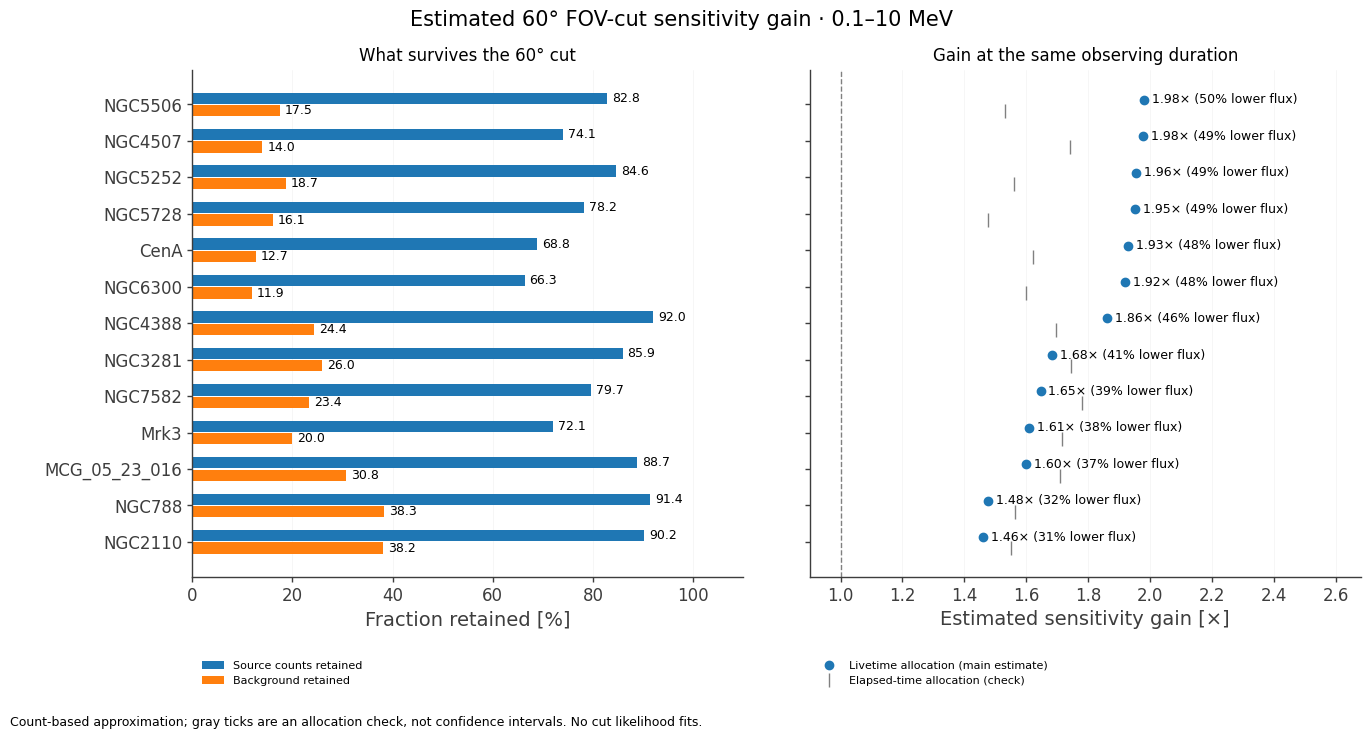

In [10]:
fov_estimates, fov_energy_counts, fov_coverage = estimate_fov_gain(
    catalog_model, selected_names, sc_orientation, fov_inputs, FOV_MAX_OFFAXIS_DEG,
)
print("FOV retained counts and sensitivity estimates")
display_tables(fov_estimates.sort_values("gain", ascending=False))
print("Common background/orientation coverage")
display_tables(fov_coverage)
# Energy-resolved expectations are also available as the in-memory fov_energy_counts table.
plot_fov_gain(fov_estimates, FOV_MAX_OFFAXIS_DEG)


## Independent Poisson trials and likelihood fits

The deterministic source expectation is folded once per source and reused for injection.
Sampling it is equivalent to drawing a new source-injected realization with fixed
position and spectrum. The fit reuses the cached point-source response.

For each realization, fit the alternative with `K >= 0` and a free background rate,
then refit the background with `K = 0` fixed. Record
$TS=2[\log L(\mathrm{source+background})-\log L(\mathrm{background})]$.
Negative TS beyond a small numerical tolerance and nonfinite likelihoods are failures.
The fit wrapper temporarily disables parameter-transform checks while threeML
constructs its result copies, restoring the prior setting even after an exception.
This permits the exact zero normalization with astromodels 2.5.1.

Failed trials remain in the in-memory table with their errors; they are not replaced
by zero TS. The displayed summary reports their number.
A failed trial makes the source's detection classification inconclusive until rerun.

At a preselected position and fixed spectral shape, $Z\approx\sqrt{TS}$ is the usual
one-sided asymptotic approximation for a nonnegative signal amplitude. It is not an
exact finite-count calibration or a correction for searching many sources. We use
median TS >= 9 as an Approximate 3-sigma criterion.


In [11]:
def draw_trial(signal, background, rng):
    if signal.axes != background.axes:
        raise ValueError("Signal/background axes do not match")
    counts = rng.poisson(np.asarray(signal.contents, dtype=float))
    counts += rng.poisson(np.asarray(background.contents, dtype=float))
    histogram = Histogram(background.axes)
    histogram[:] = counts
    return EmCDSBinnedData(histogram)


def checked_ts(loglike_signal, loglike_null, tolerance=1e-4):
    if not np.all(np.isfinite([loglike_signal, loglike_null])):
        raise ValueError("Nonfinite fitted likelihood")
    ts_raw = 2 * (loglike_signal - loglike_null)
    if ts_raw < -tolerance:
        raise ValueError(f"Materially negative TS: {ts_raw:.6g}")
    return max(0.0, ts_raw), ts_raw


def fit_without_transforms(analysis):
    # threeML clones the fitted model when building its results. astromodels
    # restores Cutoff_powerlaw's default log transform in that clone, which
    # otherwise rejects our zero lower bound even after remove_transformation().
    # Disable transformation checks during fitting/result construction only;
    # restore the user's setting even if a fit raises. Run trials sequentially.
    previous = astromodels_config.modeling.use_parameter_transforms
    try:
        astromodels_config.modeling.use_parameter_transforms = False
        # A results-only clone may internally represent exact zero as log10(0).
        # Suppress only that known warning; retain all other numerical warnings.
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="divide by zero encountered in _log10",
                                    category=RuntimeWarning)
            analysis.fit(compute_covariance=False, quiet=True, n_samples=1)
    finally:
        astromodels_config.modeling.use_parameter_transforms = previous


def fit_trial(model, folding, signal, background, orientation, rate_hz, rng):
    source = next(iter(model.point_sources.values()))
    shape = source.spectrum.main.shape
    catalog_K = shape.K.value
    result = {"status": "failed", "error": "", "ts": np.nan, "ts_raw": np.nan,
              "loglike_signal": np.nan, "loglike_null": np.nan,
              "K_fit_ph_cm2_s_keV": np.nan, "background_rate_fit_hz": np.nan,
              "background_rate_null_hz": np.nan}
    plugin = None
    try:
        shape.K.value, shape.K.free = catalog_K, True
        data = draw_trial(signal, background, rng)
        bkg = FreeNormBinnedBackground({"Background": background},
                                      sc_history=orientation, copy=True)
        likelihood = PoissonLikelihood(data, folding, bkg)
        plugin = ThreeMLPluginInterface("cosi", likelihood, folding, bkg)
        # FreeNormBinnedBackground normalizes the template to unit integral.
        # Its amplitude is counts/livetime in Hz, not a dimensionless scale.
        plugin.bkg_parameter["Background"] = Parameter(
            "Background", rate_hz, min_value=0, max_value=None,
            delta=0.05 * rate_hz, unit=u.Hz,
        )
        analysis = JointLikelihood(model, DataList(plugin), verbose=False)
        analysis.set_minimizer("minuit")
        fit_without_transforms(analysis)
        result["loglike_signal"] = float(plugin.get_log_like())
        result["K_fit_ph_cm2_s_keV"] = shape.K.value
        result["background_rate_fit_hz"] = plugin.bkg_parameter["Background"].value

        shape.K.value, shape.K.free = 0.0, False
        fit_without_transforms(analysis)
        result["loglike_null"] = float(plugin.get_log_like())
        result["background_rate_null_hz"] = plugin.bkg_parameter["Background"].value
        result["ts"], result["ts_raw"] = checked_ts(
            result["loglike_signal"], result["loglike_null"],
        )
        result["status"] = "ok"
    except Exception as exc:
        result["error"] = f"{type(exc).__name__}: {exc}"
    finally:
        shape.K.value, shape.K.free = catalog_K, True
        # JointLikelihood attaches its nuisance parameters to the model.
        # Remove them so the next trial starts with a clean source-only model.
        if plugin is not None:
            for parameter in plugin.nuisance_parameters.values():
                if parameter.name in model:
                    model.remove_external_parameter(parameter.name)
    return result


def summarize_trials(trials, flux_table, exposure_scale=8.0, threshold=9.0):
    summaries = []
    for source in flux_table.to_dict("records"):
        group = trials.loc[trials["source"] == source["source"]]
        valid = group.loc[(group["status"] == "ok") & np.isfinite(group["ts"]), "ts"]
        median = float(valid.median()) if len(valid) else np.nan
        failures = len(group) - len(valid)
        complete = len(group) > 0 and failures == 0
        summaries.append({
            **source, "n_trials": len(group), "n_valid": len(valid), "n_failed": failures,
            "ts_threshold": threshold, "median_ts_3mo": median, "approx_local_sigma_3mo": np.sqrt(median),
            "median_ts_2yr_approx": exposure_scale * median,
            "approx_local_sigma_2yr": np.sqrt(exposure_scale * median),
            "passes_ts_threshold_3mo": bool(median >= threshold) if complete else None,
            "passes_ts_threshold_2yr_approx": bool(exposure_scale * median >= threshold) if complete else None,
            "classification_status": "complete" if complete else "inconclusive_fit_failures",
        })
    return pd.DataFrame(summaries)


In [12]:
# Results remain in memory and are displayed below. Rerunning replaces the variables.
run_metadata = {
    "model_path": str(MODEL_PATH.resolve()),
    "model_sha256": hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest(),
    "source_names": selected_names, "n_realizations": N_REALIZATIONS,
    "random_seed": RANDOM_SEED, "energy_band_keV": ENERGY_BAND_KEV,
    "livetime_s": livetime_s, "nominal_duration_months": 3,
    "exposure_scale_2yr": EXPOSURE_SCALE_2YR, "ts_threshold": TS_THRESHOLD,
    "background_floor_counts": BACKGROUND_FLOOR_COUNTS,
    "background_rate_hz": background_rate_hz,
    "files": {key: {"path": str(paths[key]), "md5": checksum}
              for key, (_, checksum) in FILES.items()},
}
all_trials, diagnostics = [], []
with FullDetectorResponse.open(paths["response"]) as detector_response:
    check_response_axes(detector_response, background, ENERGY_BAND_KEV)
    for name in selected_names:
        print(f"Preparing {name} ({N_REALIZATIONS} trials)...", flush=True)
        model = isolated_model(catalog_model, name)
        folding, signal = make_folding(model, detector_response, background, sc_orientation)
        source_counts = np.asarray(signal.contents, dtype=float)
        in_empty = float(source_counts[empty_background_bins].sum())
        diagnostics.append({
            "source": name, "expected_source_counts_3mo": float(source_counts.sum()),
            "n_floored_background_bins": int(empty_background_bins.sum()),
            "expected_signal_counts_in_floored_bins": in_empty,
        })
        if in_empty > 0.1:
            print(f"  Review background: {in_empty:.3g} expected signal counts in floored bins.")
        # Use the source's index in the original catalog, so selecting a subset
        # does not change its random stream.
        source_index = list(catalog_model.point_sources).index(name)
        rng = np.random.default_rng(np.random.SeedSequence([RANDOM_SEED, source_index]))
        for trial in range(N_REALIZATIONS):
            result = fit_trial(model, folding, signal, background, sc_orientation,
                               background_rate_hz, rng)
            all_trials.append({"source": name, "trial": trial, **result})
            print(f"  {trial + 1}/{N_REALIZATIONS}: {result['status']}; TS={result['ts']:.3g}", flush=True)
            if result["status"] != "ok":
                print("   ", result["error"])
        trials = pd.DataFrame(all_trials)
        completed_fluxes = catalog_table[catalog_table["source"].isin(trials["source"])]
        summary = summarize_trials(trials, completed_fluxes, EXPOSURE_SCALE_2YR, TS_THRESHOLD)
        summary = summary.merge(pd.DataFrame(diagnostics), on="source", validate="one_to_one")
        del folding, signal, model

print("Trial-level results")
display_tables(trials)
print("Source summary")
display_tables(summary.sort_values("median_ts_3mo", ascending=False))
print("Run configuration")
display_tables(pd.DataFrame([{"setting": key, "value": str(value)} for key, value in run_metadata.items()]))


Preparing CenA (20 trials)...


12:38:54 INFO      set the minimizer to minuit                                             ]8;id=973127;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=361703;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to MINUIT                                             ]8;id=350733;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=27399;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1034\1034]8;;\

  1/20: ok; TS=167


         INFO      set the minimizer to minuit                                             ]8;id=196388;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=61346;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

...

,source,trial,status,error,ts,ts_raw,loglike_signal,loglike_null,K_fit_ph_cm2_s_keV,background_rate_fit_hz,background_rate_null_hz
0,CenA,0,ok,,167.359305,1.673593e+02,1.069418e+09,1.069418e+09,1.532001e-01,25.627758,25.649967
1,CenA,1,ok,,99.666502,9.966650e+01,1.069416e+09,1.069416e+09,1.182142e-01,25.632847,25.650007
2,CenA,2,ok,,105.706155,1.057062e+02,1.069383e+09,1.069383e+09,1.217068e-01,25.631512,25.649162
3,CenA,3,ok,,143.422311,1.434223e+02,1.069376e+09,1.069376e+09,1.418359e-01,25.628400,25.648966
4,CenA,4,ok,,145.319374,1.453194e+02,1.069355e+09,1.069355e+09,1.426860e-01,25.627601,25.648283
5,CenA,5,ok,,156.059227,1.560592e+02,1.069318e+09,1.069318e+09,1.479528e-01,25.625896,25.647341
6,CenA,6,ok,,173.139427,1.731394e+02,1.069532e+09,1.069532e+09,1.557902e-01,25.629714,25.652291
7,CenA,7,ok,,171.164135,1.711641e+02,1.069498e+09,1.069498e+09,1.549103e-01,25.629182,25.651634
8,CenA,8,ok,,148.756156,1.487562e+02,1.069408e+09,1.069408e+09,1.443915e-01,25.628675,25.649608
9,CenA,9,ok,,150.740035,1.507400e+02,1.069326e+09,1.069326e+09,1.453659e-01,25.626812,25.647885


Source summary


,source,ra_deg,dec_deg,gamma,ecut_keV,K_ph_cm2_s_keV,band_min_keV,band_max_keV,photon_flux_0p1_10_MeV_ph_cm2_s,energy_flux_0p1_10_MeV_erg_cm2_s,n_trials,n_valid,n_failed,ts_threshold,median_ts_3mo,approx_local_sigma_3mo,median_ts_2yr_approx,approx_local_sigma_2yr,passes_ts_threshold_3mo,passes_ts_threshold_2yr_approx,classification_status,expected_source_counts_3mo,n_floored_background_bins,expected_signal_counts_in_floored_bins
0,CenA,201.3651,-43.0191,1.765,550.0,0.142014,100.0,10000.0,0.002911,1.116576e-09,20,20,0,9.0,146.518968,12.104502,1172.151742,34.236702,True,True,complete,135363.199490,11530,0.022145
1,NGC2110,88.0474,-7.4562,1.640,300.0,0.023406,100.0,10000.0,0.000660,2.199910e-10,20,20,0,9.0,37.918804,6.157825,303.350434,17.416958,True,True,complete,65826.987192,11530,0.019855
2,NGC4388,186.4448,12.6621,1.640,210.0,0.021981,100.0,10000.0,0.000468,1.402858e-10,20,20,0,9.0,7.916859,2.813691,63.334870,7.958321,False,True,complete,26794.690173,11530,0.007825
3,NGC5252,204.5665,4.5426,1.670,330.0,0.008104,100.0,10000.0,0.000208,7.083737e-11,20,20,0,9.0,1.615754,1.271123,12.926028,3.595279,False,True,complete,10917.373348,11530,0.002444
4,Mrk3,93.9015,71.0375,1.520,150.0,0.008366,100.0,10000.0,0.000233,6.501604e-11,20,20,0,9.0,1.520332,1.233017,12.162653,3.487500,False,True,complete,9255.170772,11530,0.001094
5,MCG_05_23_016,146.9173,-30.9489,1.930,150.0,0.057455,100.0,10000.0,0.000202,5.265450e-11,20,20,0,9.0,0.911237,0.954587,7.289896,2.699981,False,False,complete,12051.023283,11530,0.000511
9,NGC5506,213.3119,-3.2075,1.790,110.0,0.044336,100.0,10000.0,0.000214,5.298533e-11,20,20,0,9.0,0.826779,0.909274,6.614234,2.571815,False,False,complete,7096.763688,11530,0.001216
10,NGC4507,188.9026,-39.9093,1.410,80.0,0.009752,100.0,10000.0,0.000186,4.445333e-11,20,20,0,9.0,0.607979,0.779730,4.863830,2.205409,False,False,complete,5776.049720,11530,0.001289
6,NGC7582,349.5979,-42.3706,1.700,200.0,0.008365,100.0,10000.0,0.000125,3.658744e-11,20,19,1,9.0,0.482315,0.694489,3.858522,1.964312,None,None,inconclusive_fit_failures,7606.892061,11530,0.000935
8,NGC788,30.2769,-6.8155,1.700,200.0,0.007880,100.0,10000.0,0.000118,3.446637e-11,20,20,0,9.0,0.367024,0.605825,2.936193,1.713532,False,False,complete,10430.690955,11530,0.003304


Run configuration


,setting,value
0,model_path,/Users/parshadkp/Software/AGN-HE-detectability...
1,model_sha256,bc95068081ec5fc87a6ef5876e28b56440008cb7722476...
2,source_names,"['CenA', 'NGC2110', 'NGC4388', 'NGC5252', 'Mrk..."
3,n_realizations,20
4,random_seed,20260916
5,energy_band_keV,"(100.0, 10000.0)"
6,livetime_s,6579555.0
7,nominal_duration_months,3
8,exposure_scale_2yr,8.0
9,ts_threshold,9.0


## TS distributions and approximate two-year significance

For steady flux and comparable observing efficiency and background conditions,
$TS$ approximately grows with exposure in the background-dominated regime:

$$TS_{2\,\mathrm{yr}}\approx8\,TS_{3\,\mathrm{mo}},\qquad Z\approx\sqrt{TS}.$$

The factor eight uses nominal calendar durations; the three-month calculation
itself uses the spacecraft history's actual livetime. This extrapolation is not
a full two-year orbit simulation and can fail with source variability, changing
background, sparse counts, or systematic errors. No flux threshold has been found:
a catalog flux exceeding median TS = 9 does not make that flux the sensitivity limit.
Rows with failed fits remain inconclusive; their displayed medians use successful
trials only. Inspect the failure counts and floored-background diagnostics before
interpreting a result. No trials are silently replaced or retried.


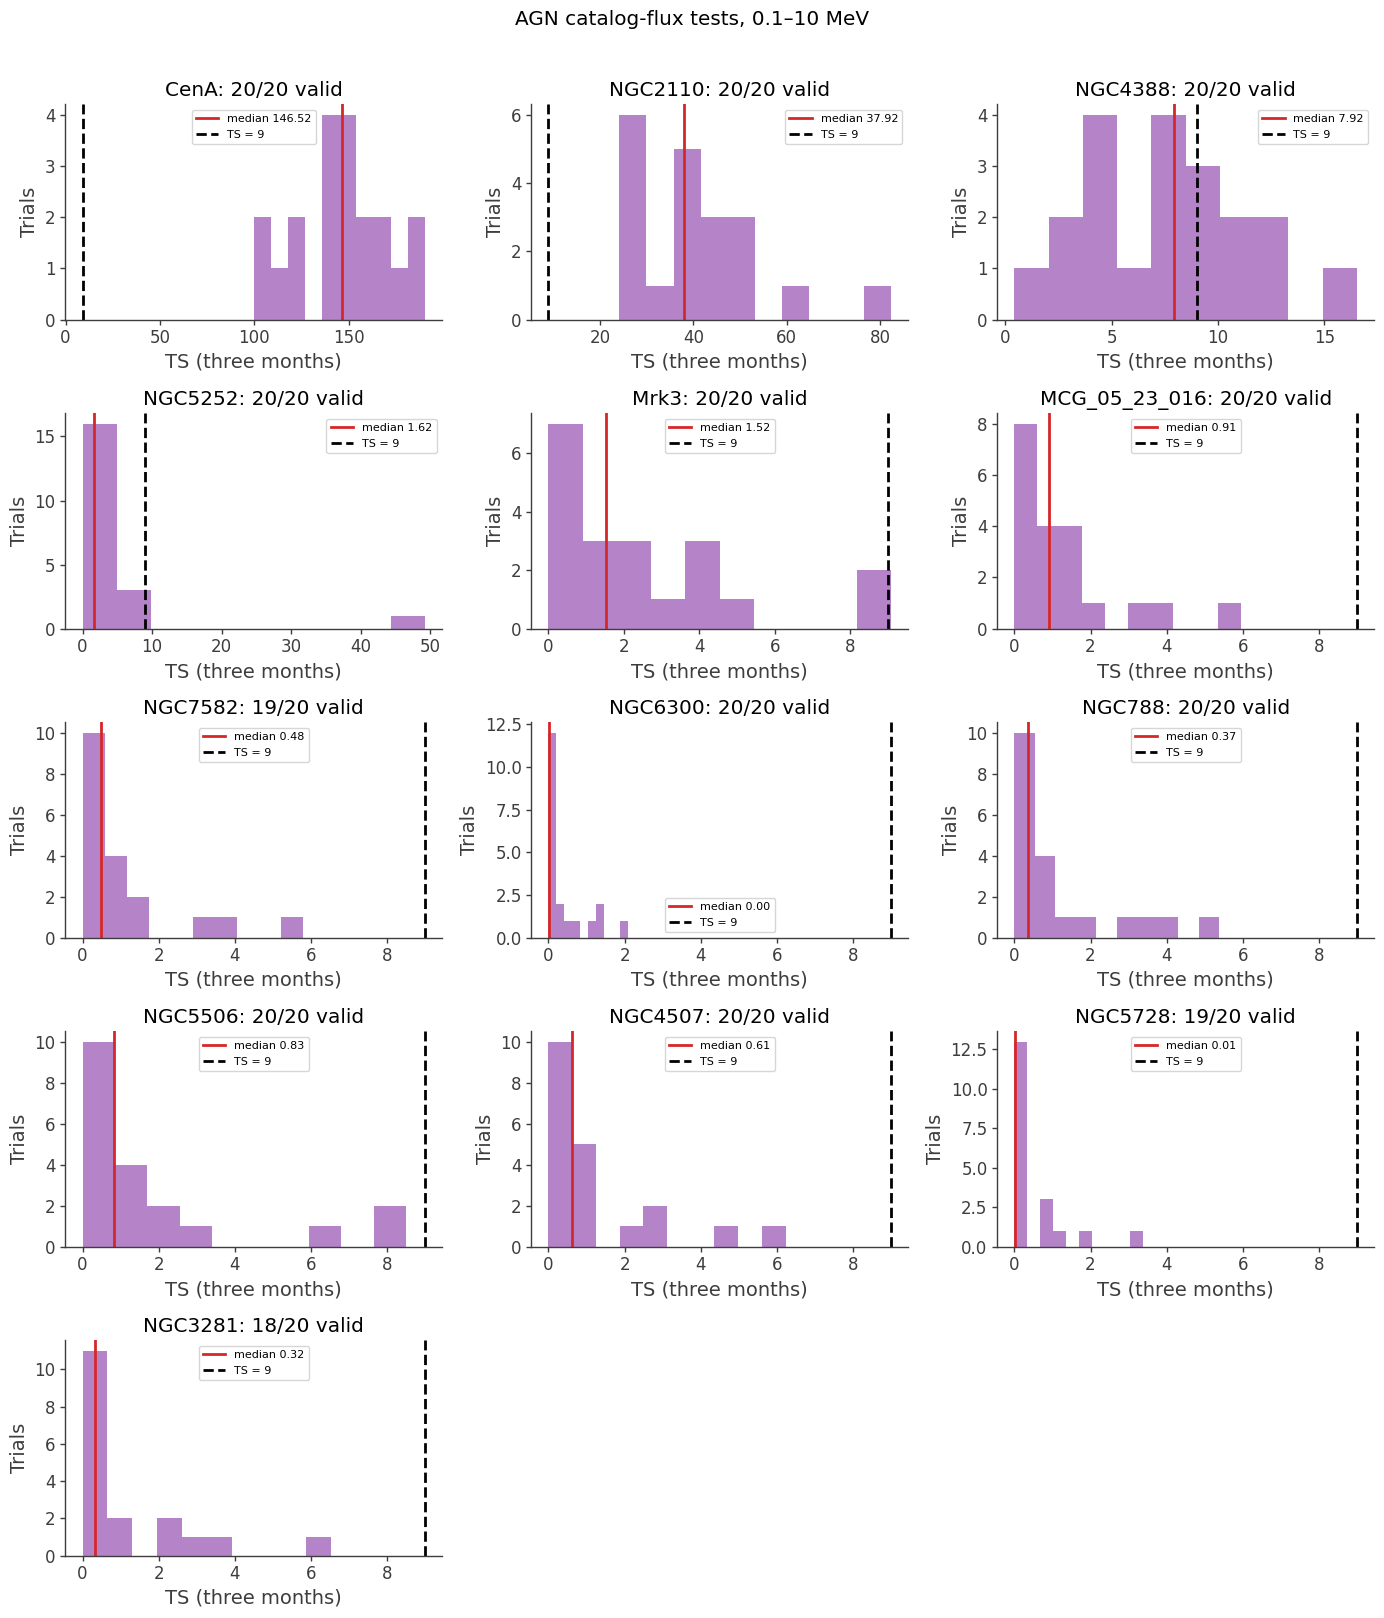

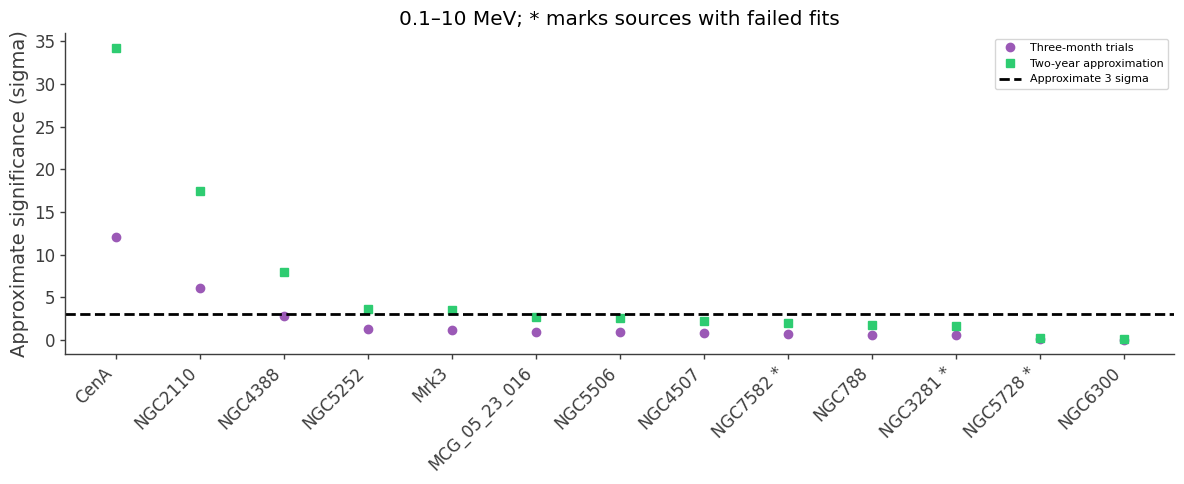

In [13]:
ncols = 3
nrows = (len(selected_names) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows), squeeze=False)
for ax, name in zip(axes.flat, selected_names):
    group = trials.loc[trials["source"] == name]
    ts = group.loc[group["status"] == "ok", "ts"].dropna()
    if len(ts):
        ax.hist(ts, bins=min(10, len(ts)), alpha=0.75)
        ax.axvline(ts.median(), color="tab:red", label=f"median {ts.median():.2f}")
    ax.axvline(TS_THRESHOLD, color="black", linestyle="--", label="TS = 9")
    ax.set(title=f"{name}: {len(ts)}/{len(group)} valid", xlabel="TS (three months)", ylabel="Trials")
    ax.legend(fontsize=8)
for ax in list(axes.flat)[len(selected_names):]:
    ax.set_visible(False)
fig.suptitle("AGN catalog-flux tests, 0.1–10 MeV", y=1.01)
fig.tight_layout()
plt.show()

ordered = summary.sort_values("median_ts_3mo", ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(ordered))
ax.plot(x, ordered["approx_local_sigma_3mo"], "o", label="Three-month trials")
ax.plot(x, ordered["approx_local_sigma_2yr"], "s", label="Two-year approximation")
ax.axhline(3, color="black", linestyle="--", label="Approximate 3 sigma")
labels = [name + (" *" if failed else "")
          for name, failed in zip(ordered["source"], ordered["n_failed"])]
ax.set_xticks(x, labels, rotation=45, ha="right")
ax.set(ylabel="Approximate significance (sigma)",
       title="0.1–10 MeV; * marks sources with failed fits")
ax.legend()
fig.tight_layout()
plt.show()


## Estimated significance after the FOV cut

After running the uncut Poisson trials, combine their median TS with the FOV gain:

$$Z_{mathrm{cut,3mo}}approx Gsqrt{mathrm{median}(TS_{mathrm{uncut,3mo}})},
qquad TS_{mathrm{cut,3mo}}approx G^2mathrm{median}(TS_{mathrm{uncut,3mo}}).$$

The two-year estimate uses the same steady-source extrapolation,
$Z_{mathrm{cut,2yr}}approxsqrt{8},Z_{mathrm{cut,3mo}}$ by default.
**These are approximate rescalings, not new likelihood fits with FOV-selected data.**
Actual improvements require a matching cut background shape and source response.
Applying a count-based gain to an imaging TS is an additional approximation; the
elapsed-time allocation result in the table is only a diagnostic of that estimate.
Sources with incomplete or failed trials, or unusable FOV exposure, are marked
inconclusive and have no reported post-cut significance or threshold classification.


Estimated post-cut significance; the uncut likelihood fits have not been rerun with FOV selections.


,source,max_offaxis_deg,n_trials,n_valid,n_failed,gain,sigma_3mo_uncut,sigma_3mo_fov_est,sigma_3mo_fov_elapsed_check,sigma_2yr_uncut_approx,sigma_2yr_fov_est,ts_3mo_fov_est,ts_2yr_fov_est,passes_ts_threshold_3mo_fov_est,passes_ts_threshold_2yr_fov_est,interpretation
0,CenA,60.0,20,20,0,1.930263,12.104502,23.364877,19.636952,34.236702,66.085851,545.917466,4367.339725,True,True,count-based estimate; no cut refit
1,NGC2110,60.0,20,20,0,1.459842,6.157825,8.989448,9.550723,17.416958,25.425999,80.810181,646.481446,True,True,count-based estimate; no cut refit
2,NGC4388,60.0,20,20,0,1.861966,2.813691,5.238998,4.775960,7.958321,14.818124,27.447099,219.576789,True,True,count-based estimate; no cut refit
3,NGC5252,60.0,20,20,0,1.956463,1.271123,2.486904,1.983786,3.595279,7.034028,6.184694,49.477550,False,True,count-based estimate; no cut refit
4,Mrk3,60.0,20,20,0,1.609605,1.233017,1.984671,2.115023,3.487500,5.613496,3.938918,31.511341,False,True,count-based estimate; no cut refit
9,NGC5506,60.0,20,20,0,1.982222,0.909274,1.802383,1.392936,2.571815,5.097910,3.248586,25.988688,False,True,count-based estimate; no cut refit
10,NGC4507,60.0,20,20,0,1.978135,0.779730,1.542411,1.357180,2.205409,4.362598,2.379033,19.032261,False,True,count-based estimate; no cut refit
5,MCG_05_23_016,60.0,20,20,0,1.599527,0.954587,1.526888,1.632794,2.699981,4.318691,2.331387,18.651094,False,True,count-based estimate; no cut refit
8,NGC788,60.0,20,20,0,1.477024,0.605825,0.894818,0.947564,1.713532,2.530928,0.800700,6.405598,False,False,count-based estimate; no cut refit
7,NGC6300,60.0,20,20,0,1.920182,0.057532,0.110473,0.091977,0.162726,0.312463,0.012204,0.097633,False,False,count-based estimate; no cut refit


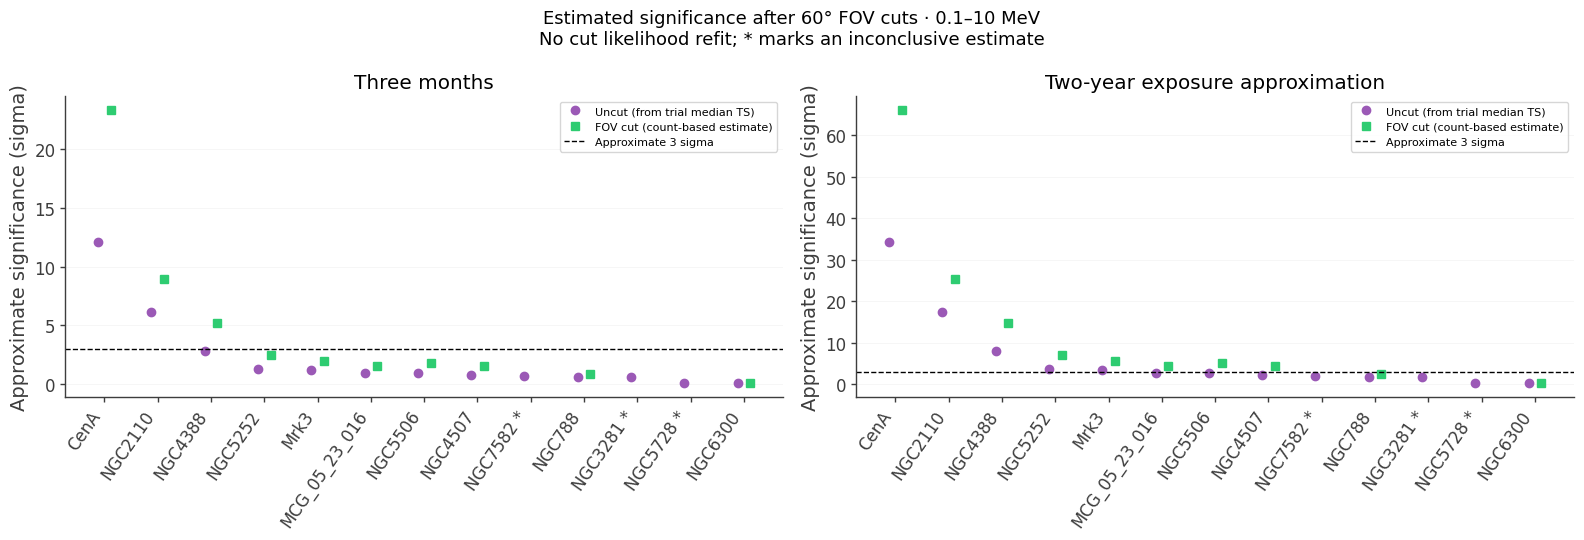

In [14]:
def estimate_cut_significance(uncut_summary, fov_estimates, exposure_scale=8.0, threshold=9.0):
    """Scale uncut significance by the count-based gain, without claiming a refit."""
    if not np.isfinite(exposure_scale) or exposure_scale <= 0:
        raise ValueError("Exposure scale must be positive")
    combined = uncut_summary.merge(
        fov_estimates[["source", "max_offaxis_deg", "gain", "gain_elapsed_time", "status"]],
        on="source", how="left", validate="one_to_one",
    )
    if combined["status"].isna().any():
        raise ValueError("Run the FOV calculation for every source in the trial summary")
    valid = ((combined["n_trials"] > 0) & (combined["n_valid"] == combined["n_trials"])
             & (combined["n_failed"] == 0) & (combined["status"] == "ok")
             & np.isfinite(combined["median_ts_3mo"]) & (combined["median_ts_3mo"] >= 0)
             & np.isfinite(combined["gain"]) & (combined["gain"] > 0))
    result = combined[["source", "max_offaxis_deg", "n_trials", "n_valid", "n_failed", "gain"]].copy()
    result["sigma_3mo_uncut"] = np.sqrt(combined["median_ts_3mo"])
    result["sigma_3mo_fov_est"] = (result["sigma_3mo_uncut"] * combined["gain"]).where(valid)
    result["sigma_3mo_fov_elapsed_check"] = (result["sigma_3mo_uncut"] * combined["gain_elapsed_time"]).where(valid)
    result["sigma_2yr_uncut_approx"] = np.sqrt(exposure_scale) * result["sigma_3mo_uncut"]
    result["sigma_2yr_fov_est"] = np.sqrt(exposure_scale) * result["sigma_3mo_fov_est"]
    result["ts_3mo_fov_est"] = result["sigma_3mo_fov_est"] ** 2
    result["ts_2yr_fov_est"] = exposure_scale * result["ts_3mo_fov_est"]
    for period in ("3mo", "2yr"):
        result[f"passes_ts_threshold_{period}_fov_est"] = pd.Series(
            np.where(valid, result[f"ts_{period}_fov_est"] >= threshold, None), dtype="boolean",
        )
    result["interpretation"] = np.where(valid, "count-based estimate; no cut refit", "inconclusive: inspect trials/FOV status")
    return result


def plot_cut_significance(comparison):
    ordered = comparison.sort_values("sigma_3mo_uncut", ascending=False)
    x = np.arange(len(ordered))
    fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharex=True)
    for axis, period, baseline, title in (
        (axes[0], "3mo", "sigma_3mo_uncut", "Three months"),
        (axes[1], "2yr", "sigma_2yr_uncut_approx", "Two-year exposure approximation"),
    ):
        axis.plot(x - .12, ordered[baseline], "o", label="Uncut (from trial median TS)")
        axis.plot(x + .12, ordered[f"sigma_{period}_fov_est"], "s", label="FOV cut (count-based estimate)")
        axis.axhline(3, color="black", ls="--", lw=1, label="Approximate 3 sigma")
        labels = [name + (" *" if pd.isna(value) else "")
                  for name, value in zip(ordered.source, ordered[f"sigma_{period}_fov_est"])]
        axis.set_xticks(x, labels, rotation=55, ha="right")
        axis.set(title=title, ylabel="Approximate significance (sigma)")
        axis.grid(axis="y", alpha=.2)
        axis.legend(fontsize=8)
    angles = ", ".join(f"{angle:g}°" for angle in sorted(ordered.max_offaxis_deg.unique()))
    fig.suptitle(f"Estimated significance after {angles} FOV cuts · 0.1–10 MeV\n"
                 "No cut likelihood refit; * marks an inconclusive estimate", fontsize=13)
    fig.tight_layout()
    plt.show()


fov_significance = estimate_cut_significance(summary, fov_estimates, EXPOSURE_SCALE_2YR, TS_THRESHOLD)
print("Estimated post-cut significance; the uncut likelihood fits have not been rerun with FOV selections.")
display_tables(fov_significance.sort_values("sigma_3mo_fov_est", ascending=False))
plot_cut_significance(fov_significance)
